# Load modules

In [27]:
import xarray as xr
import pyproj
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

# Define directories

In [ ]:
#INALT60 data
path_data = '/gxfs_work/geomar/smomw355/model_data/ocean-only/INALT60.L120-KRS0020/nemo/'
path_mask = path_data + 'suppl/2_INALT60.L120-KRS0020_mesh_mask.nc'

path_current = os.getcwd()
path_save = os.path.join(path_current, 'Fields_INALT60') 
os.makedirs(path_save, exist_ok=True)
path_save_OW = os.path.join(path_save, 'OW_proba') 
os.makedirs(path_save_OW, exist_ok=True)

path_RMS_w = !ls {path_current + 'RMS_w_model/'+'.nc'}
path_w = !ls {path_current + 'w_filtered/'+'.nc'}
path_ssh = !ls {path_current + 'SSH_filtered/'+'.nc'}
path_OW = !ls {path_current + 'strain_vorticity/'+'.nc'}

# Define region of interest

In [3]:
lon_c=15.7
lat_c=-37.8
pos_west,pos_east,pos_south,pos_north  = lon_c-2,lon_c+2,lat_c-2,lat_c+2

In [8]:
hcs=300
ds_mask = xr.open_dataset(path_mask,chunks={'x':hcs,'y':hcs})
ds_mask_region = ds_mask.where((ds_mask.nav_lat>pos_south-1.2) & (ds_mask.nav_lat<pos_north+1.2) & (ds_mask.nav_lon>pos_west-1.2) & (ds_mask.nav_lon<pos_east+1.2), drop=True)

dx=2
lon_grid=ds_mask_region.nav_lon
lat_grid=ds_mask_region.nav_lat

#Define the grid
a = pyproj.Transformer.from_crs(4326,3395).transform(lon_grid,lat_grid) # project WGS84 onto metric grid
y3 = a[0]
x3 = a[1]
x3min = np.nanmin(x3,1)
y3min = np.nanmin(y3,0)
Y3min,X3min = np.meshgrid(y3min, x3min)
x1=(x3-X3min)/1000
y1=(y3-Y3min)/1000
x_len = int(np.floor(np.amax(x1))+1)
y_len = int(np.floor(np.amax(y1))+1)
x_dim = np.linspace(0, x_len, int(x_len/dx), endpoint=False)
y_dim = np.linspace(0, y_len, int(y_len/dx), endpoint=False)
x2, y2 = np.meshgrid(x_dim, y_dim)

#Add nav_lon and nav_lat back from the interpolation 
x2_proj = x2*1000 + x3min[0]
y2_proj = y2*1000 + y3min[0]
transformer_back = pyproj.Transformer.from_crs(3395, 4326, always_xy=True)
lat2, lon2 = transformer_back.transform(y2_proj,x2_proj)

#Make square - for SQG
size_x=len(lon2[0,:])
size_y=len(lon2[:,0])

if size_y>size_x:
    delta_points=size_y-size_x
    lon2 = lon2[:size_x,:]
    lat2 = lat2[:size_x,:]
else:
    delta_points=size_x-size_y
    lon2 = lon2[:,:size_y]
    lat2 = lat2[:,:size_y]

lon2 = lon2[50:-50,50:-50]
lat2 = lat2[50:-50,50:-50]

# Read data

In [9]:
ds_w =xr.open_mfdataset(path_w)
ds_RMS_w=xr.open_mfdataset(path_RMS_w)
ds_ssh=xr.open_mfdataset(path_ssh)
ds_OW=xr.open_mfdataset(path_OW)

# Compute mean w and ssh fields

In [18]:
mean_map_w = abs(ds_w.isel(z=1).w_model).mean(dim="time_counter").compute()
mean_ssh = ds_ssh.ssh_model.mean(dim="time_counter").compute()

#Save ssh
ds_to_save = xr.Dataset(
    data_vars=dict(
        ssh_model=(["y", "x"], mean_ssh.values),
        longitude=(["y", "x"], lon2),
        latitude=(["y", "x"], lat2)
    ),
    coords=dict(
        y=("y", lat2[:,0]),
        x=("x", lon2[0,:]) 
    ) 
)
ds_to_save.to_netcdf(path=path_save+'/INALT60_mean_ssh.nc')

#Save mean w
ds_to_save = xr.Dataset(
    data_vars=dict(
        w_model=(["y", "x"], mean_map_w.values),
        longitude=(["y", "x"], lon2),
        latitude=(["y", "x"], lat2)
    ),
    coords=dict(
        y=("y", lat2[:,0]),
        x=("x", lon2[0,:]) 
    ) 
)
ds_to_save.to_netcdf(path=path_save+'/INALT60_mean_w.nc')

# Compute mean RMS w profiles

In [24]:
month_list = [[12,1,2], [3,4,5], [6,7,8], [9,10,11]]
for m in range(4):
    ds_select = ds_RMS_w.where(ds_RMS_w.time_counter.dt.month.isin(month_list[m]), drop=True)
    data = ds_select.RMS_model
    mean_profile = data.mean(dim='time_counter').compute()

    if m==0:
        ds_to_save = xr.Dataset(
                data_vars=dict(
                    RMS_w_Summer=(["z"], mean_profile.values),
                    std_w_Summer=(["z"], data.std(dim='time_counter').values)
                ),
                coords=dict(
                    z=("z", data.z.values)
                ) 
            )
    else:
        var_name = 'RMS_w_' + season_list[m]
        ds_to_save[var_name] = (('z'), mean_profile.values)
        var_name = 'std_w_' + season_list[m]
        ds_to_save[var_name] = (('z'), data.std(dim='time_counter').values)

ds_to_save.to_netcdf(path=path_save+'/INALT60_RMS_w.nc')

# Export w distributions for strain and vortice features

Text(0, 0.5, 'PDF (m day$^{-1}$)$^{-1}$')

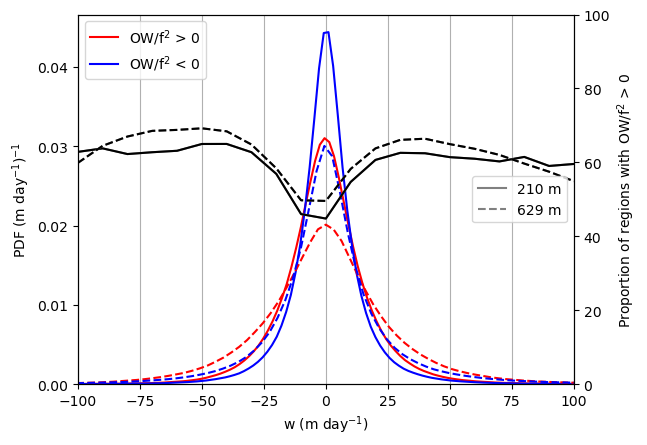

In [31]:
bins = np.arange(-100, 111, 10)

fig=plt.figure()
axs=plt.gca()
ax0=axs.twinx()

for idd in [0,2]:
    ds_OW['OW'] = ds_OW.strain**2 - ds_OW.vorticity**2
    ds_OW['OW_abs'] = abs(ds_OW.strain**2 - ds_OW.vorticity**2)

    data_depth_select = ds_OW.isel(z=idd)

    abs_OW_flat = data_depth_select.OW_abs.values.flatten()
    OW_flat = data_depth_select.OW.values.flatten()
    w_flat = data_depth_select.w.values.flatten()

    #Remove nans
    id_select = np.where(np.isnan(w_flat)==0)[0]
    OW_flat=OW_flat[id_select]
    w_flat=w_flat[id_select]
    abs_OW_flat=abs_OW_flat[id_select]

    #Find OW threshold
    thresh_OW = data_depth_select.chunk(dict(time_counter=-1)).OW_abs.quantile(0.7, dim=('time_counter', 'x', 'y')).values

    #select points above this threshold
    w_select = w_flat[np.where(abs_OW_flat>thresh_OW)[0]]
    OW_select = OW_flat[np.where(abs_OW_flat>thresh_OW)[0]]

    strain_structures = len(np.where(OW_select>0)[0])

    if idd==0:
        my_kde = sns.kdeplot(w_select[np.where(OW_select>0)[0]], color='r', ax=axs, label='OW/f$^{2}$ > 0')
        line = my_kde.lines[0]
        x, y = line.get_data()

        #Save data
        ds_to_save = xr.Dataset(
            data_vars=dict(
            PDF=("x", y)),
            coords=dict(
            x=("x", x)
                ) 
            )
        ds_to_save.to_netcdf(path=path_save_OW+'/200m_strain_proba.nc')

        my_kde = sns.kdeplot(w_select[np.where(OW_select<0)[0]], color='b', ax=axs, label='OW/f$^{2}$ < 0')
        line = my_kde.lines[0]
        x, y = line.get_data()

        #Save data
        ds_to_save = xr.Dataset(
            data_vars=dict(
            PDF=("x", y)),
            coords=dict(
            x=("x", x)
                ) 
            )
        ds_to_save.to_netcdf(path=path_save_OW+'/200m_vortices_proba.nc')
    else:
        my_kde = sns.kdeplot(w_select[np.where(OW_select>0)[0]], color='r', ax=axs, linestyle='--')
        line = my_kde.lines[0]
        x, y = line.get_data()

        #Save data
        ds_to_save = xr.Dataset(
            data_vars=dict(
            PDF=("x", y)),
            coords=dict(
            x=("x", x)
                ) 
            )
        ds_to_save.to_netcdf(path=path_save_OW+'/600m_strain_proba.nc')
        
        my_kde = sns.kdeplot(w_select[np.where(OW_select<0)[0]], color='b', ax=axs, linestyle='--')
        line = my_kde.lines[0]
        x, y = line.get_data()

        #Save data
        ds_to_save = xr.Dataset(
            data_vars=dict(
            PDF=("x", y)),
            coords=dict(
            x=("x", x)
                ) 
            )
        ds_to_save.to_netcdf(path=path_save_OW+'/600m_vortices_proba.nc')

    strain_ratio = np.zeros(len(bins)-1)
    for b in range(len(bins)-1):
        select_w=np.where((w_select>bins[b]) & (w_select<=bins[b+1]))[0]
        OW_select_w = OW_select[select_w]
        sd = np.where(OW_select_w>0)[0]

        strain_ratio[b]=len(sd)/len(select_w) * 100
    if idd==0:
        ax0.plot(bins[:-1], strain_ratio, 'grey', label=str(np.round(ds_OW.isel(z=idd).z.values))[:3]+' m')
        ax0.plot(bins[:-1], strain_ratio, 'k')
        ds_to_save = xr.Dataset(
            data_vars=dict(
                ratio=("bins", strain_ratio)),
                coords=dict(
                bins=("bins", (bins[:-1]+bins[1:])/2)
                ) 
            )
        ds_to_save.to_netcdf(path=path_save_OW+'/200m_ratio.nc')
    else:
        ax0.plot(bins[:-1], strain_ratio, 'grey', label=str(np.round(ds_OW.isel(z=idd).z.values))[:3]+' m',linestyle='--')
        ax0.plot(bins[:-1], strain_ratio, 'k',linestyle='--')
        ds_to_save = xr.Dataset(
            data_vars=dict(
                ratio=("bins", strain_ratio)),
                coords=dict(
                bins=("bins", (bins[:-1]+bins[1:])/2)
                ) 
            )
        ds_to_save.to_netcdf(path=path_save_OW+'/200m_ratio.nc')

ax0.set_xlim([-100,100])
ax0.set_ylim([0,100])
axs.grid(True, axis='x')
axs.legend(loc='upper left')
ax0.legend(loc='center right')
ax0.set_ylabel('Proportion of regions with OW/f$^{2}$ > 0')
axs.set_xlabel('w (m day$^{-1}$)')
axs.set_ylabel('PDF (m day$^{-1}$)$^{-1}$')
    